# Cellpose so far failed on Taylors approach
because the cells that are been used have irregular shape and no clear cellmembranes -> cytoplasma is also fainting.\
also segmentation has to happen on puncta images.. 
https://www.mdpi.com/2313-433X/12/7/297?utm_source=copilot.com \
\
HoVer‑Net — handles weak boundaries
CellVit‑SAM — robust across modalities
Custom U‑Net with multi‑channel inputs (e.g., raw + enhanced cytoplasm)

In [3]:
from torch.utils.data import Dataset
import cv2
import torch
import numpy as np
import glob
import tifffile as tiff
import os
import torch.nn as nn
from torch.utils.data import DataLoader
import torch.optim as optim

In [4]:
class CellDataset(Dataset):
    def __init__(self, img_dir, mask_dir):
        self.img_paths = sorted(glob.glob(os.path.join(img_dir, "*")))
        self.mask_paths = sorted(glob.glob(os.path.join(mask_dir, "*")))

        # Build dictionary: base_name → mask_path
        self.mask_dict = {}
        for m in self.mask_paths:
            base = os.path.basename(m)
            base = base.replace("_masks", "")  # remove suffix
            self.mask_dict[base] = m

        # Filter images that have a matching mask
        self.pairs = []
        for img in self.img_paths:
            base = os.path.basename(img)
            if base in self.mask_dict:
                self.pairs.append((img, self.mask_dict[base]))
            else:
                print("⚠️ No mask found for:", base)

        print("Found", len(self.pairs), "image-mask pairs")

        if len(self.pairs) == 0:
            raise ValueError("No matching image-mask pairs found.")

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]

        img = tiff.imread(img_path).astype(np.float32)
        img = img / img.max()

        mask = tiff.imread(mask_path)
        mask = (mask > 0).astype(np.float32)

        img = torch.tensor(img).unsqueeze(0)
        mask = torch.tensor(mask).unsqueeze(0)

        return img, mask


In [5]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.d1 = DoubleConv(1, 64)
        self.d2 = DoubleConv(64, 128)
        self.d3 = DoubleConv(128, 256)
        self.d4 = DoubleConv(256, 512)

        self.u1 = DoubleConv(512 + 256, 256)
        self.u2 = DoubleConv(256 + 128, 128)
        self.u3 = DoubleConv(128 + 64, 64)

        self.maxpool = nn.MaxPool2d(2)
        self.up = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=True)

        self.out = nn.Conv2d(64, 1, 1)

    def forward(self, x):
        c1 = self.d1(x)
        c2 = self.d2(self.maxpool(c1))
        c3 = self.d3(self.maxpool(c2))
        c4 = self.d4(self.maxpool(c3))

        u1 = self.up(c4)
        u1 = self.u1(torch.cat([u1, c3], dim=1))

        u2 = self.up(u1)
        u2 = self.u2(torch.cat([u2, c2], dim=1))

        u3 = self.up(u2)
        u3 = self.u3(torch.cat([u3, c1], dim=1))

        return torch.sigmoid(self.out(u3))


In [6]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")


dataset = CellDataset("cellpose_training/Data", "cellpose_training/Mask")
loader = DataLoader(dataset, batch_size=4, shuffle=True)

model = UNet().to(device).float()


criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

def dice_loss(pred, target):
    smooth = 1.
    pred = pred.view(-1)
    target = target.view(-1)
    intersection = (pred * target).sum()
    return 1 - ((2. * intersection + smooth) /
                (pred.sum() + target.sum() + smooth))

for epoch in range(30):
    for img, mask in loader:
        img = img.to(device).float()
        mask = mask.to(device).float()

        pred = model(img)
        loss = criterion(pred, mask) + dice_loss(pred, mask)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch}: {loss.item():.4f}")



Found 69 image-mask pairs
Epoch 0: 1.3027
Epoch 0: 1.3027
Epoch 1: 1.2969
Epoch 1: 1.2969
Epoch 2: 1.3336
Epoch 2: 1.3336
Epoch 3: 1.2879
Epoch 3: 1.2879
Epoch 4: 1.2951
Epoch 4: 1.2951
Epoch 5: 1.2878
Epoch 5: 1.2878
Epoch 6: 1.2478
Epoch 6: 1.2478
Epoch 7: 1.2702
Epoch 7: 1.2702
Epoch 8: 1.1108
Epoch 8: 1.1108
Epoch 9: 1.7941
Epoch 9: 1.7941
Epoch 10: 1.4292
Epoch 10: 1.4292
Epoch 11: 1.2847
Epoch 11: 1.2847
Epoch 12: 1.3063
Epoch 12: 1.3063
Epoch 13: 1.2704
Epoch 13: 1.2704
Epoch 14: 1.4815
Epoch 14: 1.4815
Epoch 15: 1.2353
Epoch 15: 1.2353
Epoch 16: 1.4224
Epoch 16: 1.4224
Epoch 17: 1.1054
Epoch 17: 1.1054
Epoch 18: 1.2329
Epoch 18: 1.2329
Epoch 19: 0.9656
Epoch 19: 0.9656
Epoch 20: 1.1279
Epoch 20: 1.1279
Epoch 21: 1.1259
Epoch 21: 1.1259
Epoch 22: 1.0957
Epoch 22: 1.0957
Epoch 23: 1.1130
Epoch 23: 1.1130
Epoch 24: 0.7257
Epoch 24: 0.7257
Epoch 25: 0.8620
Epoch 25: 0.8620
Epoch 26: 0.8635
Epoch 26: 0.8635
Epoch 27: 0.8122
Epoch 27: 0.8122
Epoch 28: 0.7020
Epoch 28: 0.7020
Epoch 29

In [7]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

model.eval()
model.to(device)

with torch.no_grad():
    # Load TIFF safely
    img = tiff.imread("cellpose_training/20251210 3nM 540-D12_NEMO_TRAF6_HOIP-KO 1um_27mol/gfp_rollingball/gfp_rollingball_0136.tif")

    # Convert to float32
    img = img.astype(np.float32)

    # Normalize (important for TIFFs)
    img = img / img.max()

    # Convert to tensor
    img = torch.tensor(img).unsqueeze(0).unsqueeze(0).float().to(device)

    # Predict
    pred = model(img)[0,0].cpu().numpy()

    # Threshold
    mask = (pred > 0.5).astype(np.uint8) * 255

cv2.imwrite("prediction.png", mask)



True

In [ ]:
import tifffile as tiff
import numpy as np
import cv2

orig = tiff.imread("cellpose_training/20251210 3nM 540-D12_NEMO_TRAF6_HOIP-KO 1um_27mol/gfp_rollingball/gfp_rollingball_0136.tif").astype(np.float32)
orig = orig / orig.max()

mask = cv2.imread("prediction.png", 0).astype(np.float32) / 255

# Create overlay (green mask on grayscale image)
overlay = np.dstack([
    orig,                 # R channel
    orig * (1-mask) + mask,  # G channel (cells highlighted)
    orig                  # B channel
])

overlay = (overlay * 255).astype(np.uint8)

cv2.imwrite("overlay.png", overlay)


True

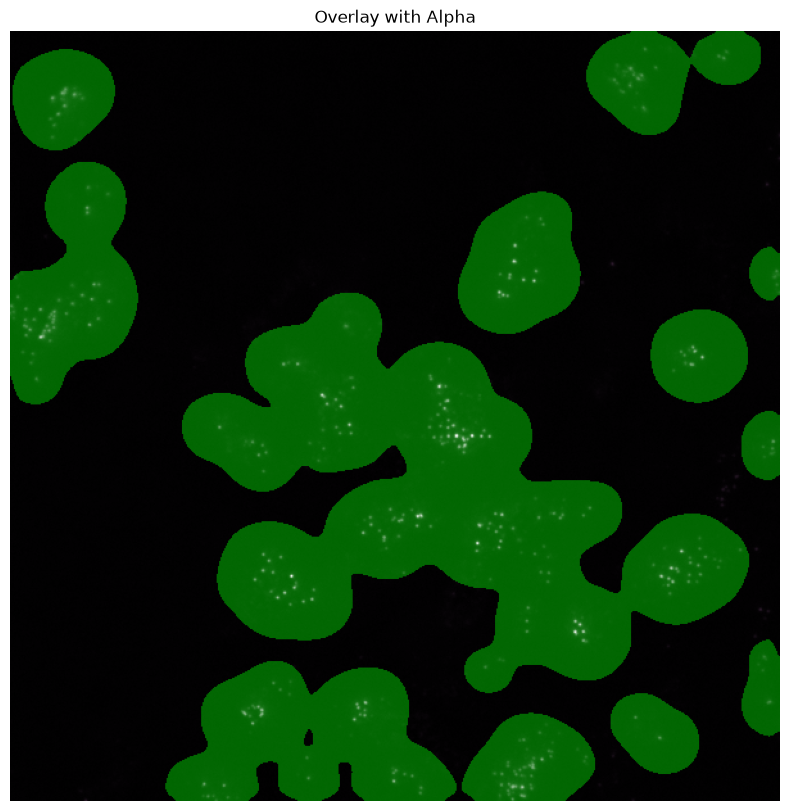

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import tifffile as tiff

# Load original TIFF
orig = tiff.imread("cellpose_training/20251210 3nM 540-D12_NEMO_TRAF6_HOIP-KO 1um_27mol/gfp_rollingball/gfp_rollingball_0136.tif").astype(np.float32)
orig = orig / orig.max()

# Load predicted mask (0–255)
mask = cv2.imread("prediction.png", 0).astype(np.float32)
mask = mask / 255.0

# Alpha value (transparency of mask)
alpha = 0.4  # adjust between 0 (invisible) and 1 (solid)

# Create overlay:
# - original image is grayscale
# - mask is shown in green with transparency
overlay = np.dstack([
    orig,                          # R channel
    orig * (1 - alpha) + mask * alpha,  # G channel (highlight)
    orig                           # B channel
])

# Plot
plt.figure(figsize=(10, 10))
plt.title("Overlay with Alpha")
plt.imshow(overlay)
plt.axis("off")
plt.show()


Detected cells: 12


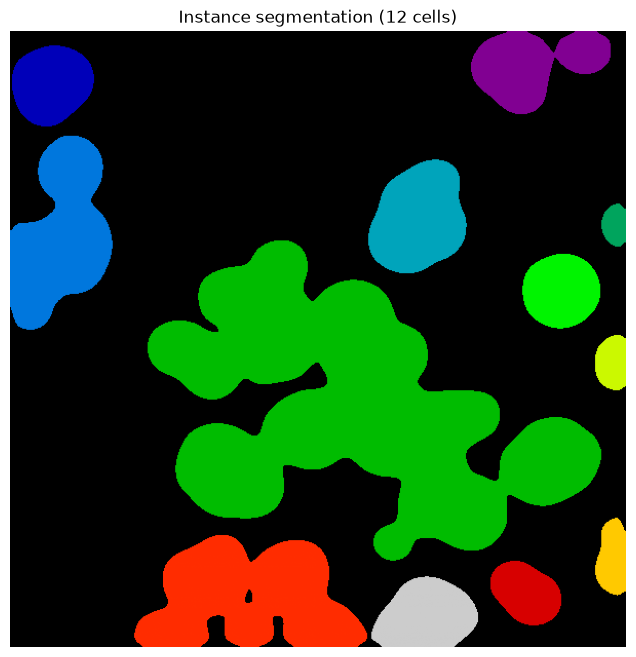

In [16]:
import numpy as np
import cv2
from skimage.measure import label
import matplotlib.pyplot as plt

# Load binary mask
mask = cv2.imread("prediction.png", 0)
mask_bin = (mask > 127).astype(np.uint8)

# Connected components → each cell gets an ID
labels = label(mask_bin, connectivity=1)
num_cells = labels.max()
print("Detected cells:", num_cells)

# Nice visualization
plt.figure(figsize=(8, 8))
plt.imshow(labels, cmap="nipy_spectral")
plt.title(f"Instance segmentation ({num_cells} cells)")
plt.axis("off")
plt.show()


Watershed cells: 34


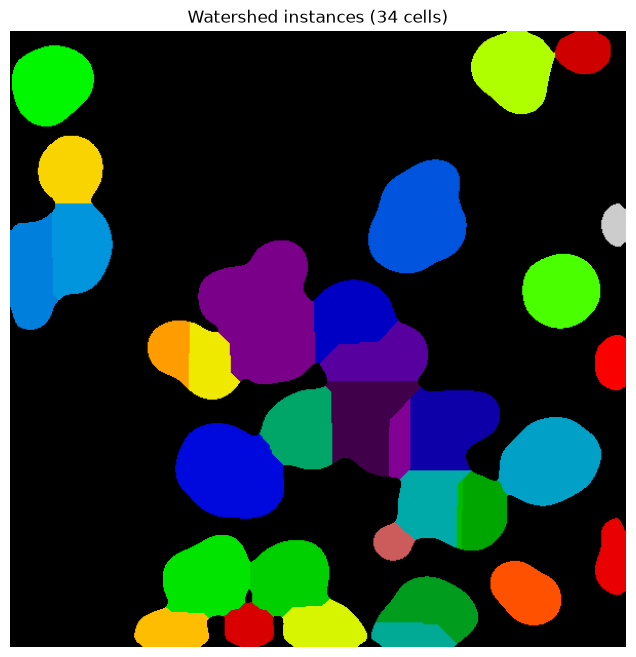

In [17]:
from scipy import ndimage as ndi
from skimage.segmentation import watershed
from skimage.feature import peak_local_max

# Distance transform
distance = ndi.distance_transform_edt(mask_bin)

# Peaks as markers
coords = peak_local_max(distance, min_distance=5, labels=mask_bin)
markers = np.zeros_like(mask_bin, dtype=int)
for i, (r, c) in enumerate(coords, start=1):
    markers[r, c] = i

# Watershed
labels_ws = watershed(-distance, markers, mask=mask_bin)
num_cells_ws = labels_ws.max()
print("Watershed cells:", num_cells_ws)

plt.figure(figsize=(8, 8))
plt.imshow(labels_ws, cmap="nipy_spectral")
plt.title(f"Watershed instances ({num_cells_ws} cells)")
plt.axis("off")
plt.show()
